## Objective 3- U-net Segmentation

 # Imports & Data Loading and Normalization


In [1]:
import tensorflow as tf
import os, cv2, math, random, PIL, PIL.Image,pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import sklearn
from tqdm import tqdm
from tensorflow import keras
from tensorflow.keras import layers,losses
from tensorflow.keras.layers import Dense,Flatten,Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Sequential, Model
#from tensorboard.plugins.hparams import api as hp
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from skimage.filters import threshold_otsu
#from sklearn.metrics import plot_confusion_matrix, ConfusionMatrixDisplay, confusion_matrix,accuracy_score, precision_score, recall_score

print("TensorFlow Version Used: ",tf.__version__)


from google.colab import drive
from PIL import Image
# Mount Google Drive to access dataset
drive.mount('/content/gdrive/')

# Define the path to raw data
raw_data_dir = '/content/gdrive/MyDrive/Colab_Notebooks/kid-dataset-no-replicas/RawData'


# Define the input size of your images and masks
input_shape = (360, 360, 1)

# Create empty lists for your data and masks
data = []

# Load the raw images
for raw_class_dir in os.listdir(raw_data_dir):
    if not os.path.isdir(os.path.join(raw_data_dir, raw_class_dir)):
        continue
    for filename in os.listdir(os.path.join(raw_data_dir, raw_class_dir)):
        raw_img = tf.keras.preprocessing.image.load_img(os.path.join(raw_data_dir, raw_class_dir, filename), target_size=(360, 360))
        raw_img = tf.keras.preprocessing.image.img_to_array(raw_img)
        data.append(raw_img)
        #print("Image Loaded")

print(len(data))



# Define the path to data annotations
annotation_data_dir = '/content/gdrive/MyDrive/Colab_Notebooks/kid-dataset-no-replicas/Annotations'

# Create empty lists for masks
masks = []

# Load image annotations
for anot_class_dir in os.listdir(annotation_data_dir):
    if not os.path.isdir(os.path.join(annotation_data_dir, anot_class_dir)):
        continue
    for filename in os.listdir(os.path.join(annotation_data_dir, anot_class_dir)):
        anot_img = tf.keras.preprocessing.image.load_img(os.path.join(annotation_data_dir, anot_class_dir, filename), target_size=(360, 360),color_mode="grayscale")
        anot_img = tf.keras.preprocessing.image.img_to_array(anot_img)
        masks.append(anot_img)  
        #print("Mask Loaded")

print(len(masks))


# Convert the data and masks lists to numpy arrays
data = np.array(data)
masks = np.array(masks)

#scalling raw data and masks
data = data / 255.0
masks = masks / 255.0

#Split the data and masks into training and testing sets
train_data, test_data, train_masks, test_masks = train_test_split(data, masks, test_size=0.2, random_state=42)

TensorFlow Version Used:  2.12.0
Mounted at /content/gdrive/
593
593


In [ ]:
max_vals = np.amax(masks, axis=(1, 2))
min_vals = np.amin(masks, axis=(1, 2))

print(max_vals)

print(min_vals)

[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.

# Model Definition

In [2]:
# Define the autoencoder model

# Encoder layers
MEH = tf.keras.layers.Input((360, 360, 3))

# Define the convolutional layers
initializer = tf.keras.initializers.RandomNormal(mean=0., stddev=1., seed = 42)
initializer2 = tf.random_uniform_initializer(minval=0, maxval=1, seed=None)

C1 = (Conv2D(32, (3, 3), activation='relu', kernel_initializer=initializer ,padding='same', input_shape=(360, 360, 3)))(MEH)
C1 = tf.keras.layers.Dropout(0.1)(C1)
C1 = (Conv2D(32, (3, 3), activation='relu', kernel_initializer=initializer, padding='same'))(C1)
M1 = (MaxPooling2D((2, 2), padding='same'))(C1) #180

C2 = (Conv2D(64, (3, 3), activation='relu', kernel_initializer=initializer, padding='same'))(M1)
C2 = tf.keras.layers.Dropout(0.1)(C2)
C2 = (Conv2D(64, (3, 3), activation='relu', kernel_initializer=initializer, padding='same'))(C2)
M2 = (MaxPooling2D((2, 2), padding='same'))(C2)#90

C3 = (Conv2D(128, (3, 3), activation='relu', kernel_initializer=initializer, padding='same'))(M2)
C3 = tf.keras.layers.Dropout(0.2)(C3)
C3 = (Conv2D(128, (3, 3), activation='relu', kernel_initializer=initializer, padding='same'))(C3)
M3 = (MaxPooling2D((2, 2), padding='same'))(C3)#45

C4 = (Conv2D(256, (3, 3), activation='relu', kernel_initializer=initializer, padding='same'))(M3)
C4 = tf.keras.layers.Dropout(0.2)(C4)
C4 = (Conv2D(256, (3, 3), activation='relu', kernel_initializer=initializer, padding='same'))(C4)
M4 = (MaxPooling2D((3, 3), padding='same'))(C4) #15

#Latent Space
C5 = (Conv2D(512, (3, 3), activation='relu', kernel_initializer=initializer, padding='same'))(M4)
C5 = tf.keras.layers.Dropout(0.3)(C5)
C5 = (Conv2D(512, (3, 3), activation='relu', kernel_initializer=initializer, padding='same'))(C5)

# Decoder layers
U6 = tf.keras.layers.Conv2DTranspose(256, (2, 2), strides=(3, 3), padding='same')(C5)#45
U6 = (tf.keras.layers.concatenate([U6,C4]))
C6 = (Conv2D(256, (3, 3), activation='relu', kernel_initializer=initializer2, padding='same'))(U6)
C6 = tf.keras.layers.Dropout(0.3)(C6)
C6 = (Conv2D(256, (3, 3), activation='relu', kernel_initializer=initializer2, padding='same'))(C6)

U7 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(C6)
U7 = (tf.keras.layers.concatenate([U7,C3]))##
C7 = (Conv2D(128, (3, 3), activation='relu', kernel_initializer=initializer2, padding='same'))(U7)
C7 = tf.keras.layers.Dropout(0.3)(C7)
C7 = (Conv2D(128, (3, 3), activation='relu', kernel_initializer=initializer2, padding='same'))(C7)

U8 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(C7)
U8 = (tf.keras.layers.concatenate([U8,C2]))##
C8 = (Conv2D(64, (3, 3), activation='relu', kernel_initializer=initializer2,  padding='same'))(U8)
C8 = tf.keras.layers.Dropout(0.3)(C8)
C8 = (Conv2D(64, (3, 3), activation='relu', kernel_initializer=initializer2, padding='same'))(C8)

U9 = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(C8)
U9 = (tf.keras.layers.concatenate([U9,C1]))##
C9 = (Conv2D(32, (3, 3), activation='relu', kernel_initializer=initializer2, padding='same'))(U9)
C9 = tf.keras.layers.Dropout(0.3)(C9)
C9 = (Conv2D(32, (3, 3), activation='relu',  kernel_initializer=initializer2,padding='same'))(C9)

output = (Conv2D(1, (1, 1), activation='sigmoid',  kernel_initializer=initializer2,padding='same'))(U9)

#model = tf.keras.Model(inputs=[MEH], outputs=[output])
model = tf.keras.models.Model(inputs=MEH, outputs=output)
model.load_weights('/content/gdrive/MyDrive/Colab_Notebooks/amrch27_test2.h5')
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='MSE')

#Model Summary
#model.summary()
#c5 = tf.keras.layers.Dropout(0.3)(c5)
#c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

# Model Training

In [ ]:
#history = model.fit(train_data, train_masks, epochs = 150, validation_data = (test_data, test_masks))

In [ ]:
#model.save_weights('/content/gdrive/MyDrive/Colab_Notebooks/amrch27_test2.h5')

# Predictions & Visualisation

4/4 [==============================] - 25s 2s/step


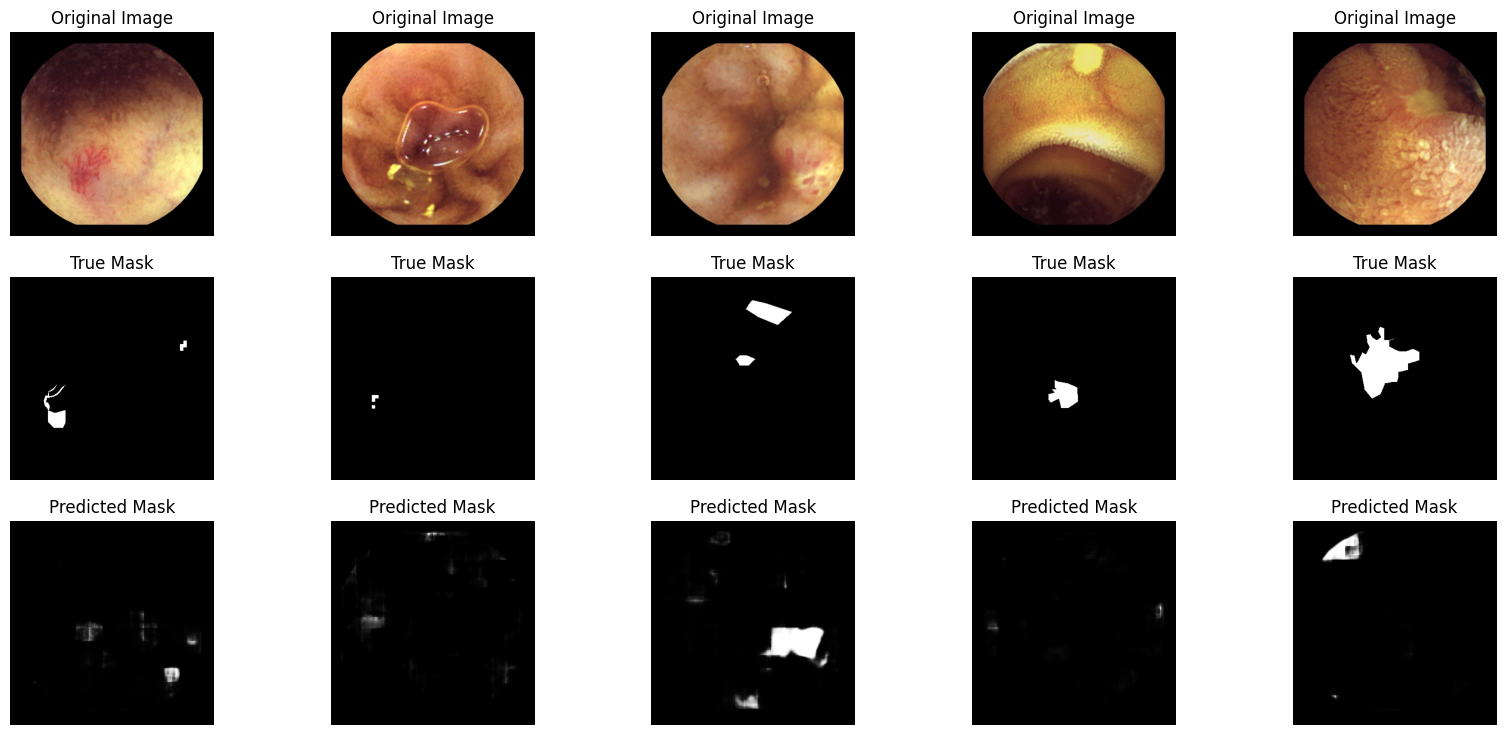

In [3]:
# Make predictions on the test data
pred_masks = model.predict(test_data)


# Select 10 random samples from the test data
sample_indexes = np.random.choice(len(test_data), size=5, replace=False)

#sample_indexes = [2,44,150,250,400] #image indexes where the masks have   white parts
#sample_indexes = [2,44,150,250,408]

# Create a figure with 10 subplots
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 9) )

# Loop over each sample index
for i, index in enumerate(sample_indexes):
    # Get the corresponding raw image and mask
    raw_img = test_data[index]
    true_mask = test_masks[index]
    pred_mask = pred_masks[index]
    
    # Plot the raw image in the first row with a title
    axes[0, i].imshow(raw_img, cmap='gray')
    axes[0, i].axis("off")
    axes[0, i].set_title("Original Image")
    
    # Plot the true mask in the second row (left column) with a title
    axes[1, i].imshow(true_mask, cmap='gray')
    axes[1, i].axis("off")
    axes[1, i].set_title("True Mask")
    
    # Plot the predicted mask in the second row (right column) with a title
    axes[2, i].imshow(pred_mask, cmap='gray')
    axes[2, i].axis("off")
    axes[2, i].set_title("Predicted Mask")
    
# Show the plot
plt.show()

# Model Evaluation

1/1 [==============================] - 0s 24ms/step
Minimum MSE value: 0.0011120258
1/1 [==============================] - 0s 22ms/step


Text(0.5, 1.0, 'Predicted Mask')

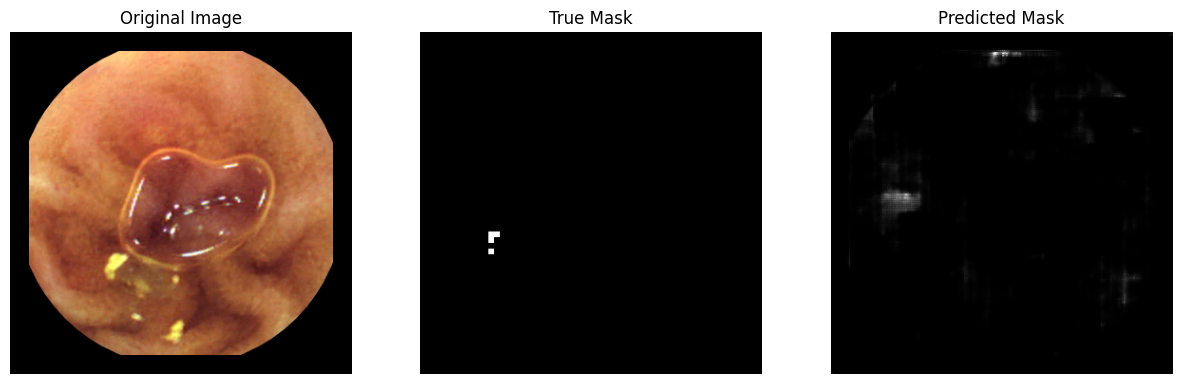

In [4]:
from sklearn.metrics import mean_squared_error

# Evaluate the model on the validation data
mse_values = []
for i in range(len(test_data)):
    # Get the corresponding raw image and mask
    raw_img = test_data[i]
    true_mask = test_masks[i]

    # Make a prediction on the raw image
    pred_mask = model.predict(np.array([raw_img]))
    pred_mask= tf.reshape(pred_mask, (360, 360, 1))

    # Calculate the MSE between the true mask and predicted mask
    mse = np.square(np.subtract(true_mask,pred_mask)).mean()
    mse_values.append(mse)

# Find the index of the minimum MSE value
min_mse_index = mse_values.index(min(mse_values))
min_mse_value = mse_values[min_mse_index]

print("Minimum MSE value:", min_mse_value)

# Plot the original image, predicted mask, and true mask for the image with minimum MSE
raw_img = test_data[min_mse_index]
true_mask = test_masks[min_mse_index]
pred_mask = model.predict(np.array([raw_img]))
pred_mask= tf.reshape(pred_mask, (360, 360, 1))

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
# Plot the raw image in the first row with a title
axes[0].imshow(raw_img, cmap='gray')
axes[0].axis("off")
axes[0].set_title("Original Image")
    
# Plot the true mask in the second row (left column) with a title
axes[1].imshow(true_mask, cmap='gray')
axes[1].axis("off")
axes[1].set_title("True Mask")
    
# Plot the predicted mask in the second row (right column) with a title
axes[2].imshow(pred_mask, cmap='gray')
axes[2].axis("off")
axes[2].set_title("Predicted Mask")

In [ ]:
print(len(pred_mask))

360


In [ ]:
print(len(test_data))

119


In [ ]:
max_vals2 = np.amax(pred_mask, axis=(1, 2))
min_vals2 = np.amin(pred_mask, axis=(1, 2))

print(max_vals2)

print(min_vals2)

[2.73500872e-03 1.83363212e-03 3.01512284e-03 2.66428967e-03
 4.66927770e-04 4.72530461e-04 2.40261375e-04 2.52818427e-04
 1.55663205e-04 1.73717141e-04 1.73975903e-04 1.90536288e-04
 1.34977832e-04 1.52524823e-04 1.43527446e-04 1.58274357e-04
 2.02001334e-04 3.78414348e-04 1.42121222e-03 1.36232590e-02
 1.10110827e-02 3.05098370e-02 3.27051058e-02 2.95276362e-02
 2.45919712e-02 1.74143370e-02 1.50554506e-02 1.28520373e-02
 1.02795456e-02 8.30053817e-03 8.93381145e-03 8.47297162e-03
 9.31223854e-03 7.93048739e-03 4.69999341e-03 3.81034869e-03
 2.11343239e-03 1.39177474e-03 9.71372938e-04 8.68144329e-04
 9.36625933e-04 6.17352140e-04 6.19938190e-04 6.37730700e-04
 1.08577521e-03 9.51136753e-04 1.26488390e-03 1.14814669e-03
 1.38869579e-03 1.07761961e-03 1.36528595e-03 1.13031687e-03
 1.54085900e-03 2.76712584e-03 3.52122774e-03 3.69776343e-03
 5.04708011e-03 3.36696417e-03 3.50236823e-03 2.87382863e-03
 3.47240758e-03 3.27290501e-03 3.08814133e-03 2.57553696e-03
 4.14543832e-03 4.439145

In [ ]:
countz = 0
for i in range(len(pred_masks)):
    orig_mask = masks[i]
    num_white_pixels = np.count_nonzero(orig_mask == 1)
    if num_white_pixels <= 97200:
        countz += 1

print(countz)

119


In [ ]:
print(np.sum(test_masks == 1) )
print(np.sum(test_masks == 0) )

1551722
13870678


# Metrics (TPR / TNR)

In [12]:
overlap,num_white_pixels_list,num_black_pixels_list = [], [] , []
count, true_positives, threshold_value, predictions_binary, max_vals2, min_vals2,true_positives,true_negatives,num_white_pixels,num_black_pixels = 0,0,0,0,0,0,0,0,0,0
count1, count2, count3, count4, count5 = 0,0,0,0,0
count1o, count2o, count3o, count4o, count5o = 0,0,0,0,0

for i in range(len(pred_masks)):
    # Get new names for the array
    orig_mask = test_masks[i]
    pred_mask = pred_masks[i]

    # Normalize predictions
    pred_mask_norm = pred_mask / np.max(pred_mask)
      
    # Calculate Threshold
    threshold_value = threshold_otsu(pred_mask_norm)

    # apply thresholding to the predictions
    predictions_binary = np.where(pred_mask_norm >= threshold_value, 1, 0)
   
  
    #Known Positives
    num_white_pixels = num_white_pixels + np.sum(orig_mask == 1)
    # Append the number of white pixels to the list
    num_white_pixels_list.append(num_white_pixels)

    #Known Negatives
    num_black_pixels = num_black_pixels + np.sum(orig_mask == 0)
    # Append the number of black pixels to the list
    num_black_pixels_list.append(num_black_pixels)  

    #True Positives
    true_temp = orig_mask * predictions_binary
    temp_sum = np.sum(predictions_binary==1)
    true_positives = true_positives + np.sum(true_temp==1)
    
    #True Negatives
    # Step 1: create a mask with all pixels set to 1
    # temp_mask = np.ones(orig_mask.shape)

    # Step 2: invert the original and predicted images
    y_true_inv = abs(1 - orig_mask)
    y_pred_inv = abs(1 - predictions_binary)

    # Step 3: multiply the inverted images and the mask to get an image with 1s in the locations of true negatives and 0s elsewhere
    true_negatives_temp  = y_true_inv * y_pred_inv
    #true_negatives = true_negatives* temp_mask

    # Step 4: count the number of white pixels in the true_negatives image to get the total number of true negatives
    true_negative_count = np.sum(true_negatives_temp == 1)
    true_negatives = true_negatives + true_negative_count

    #overlap_mask= np.logical_and(orig_mask, pred_mask_norm)

    if 97200 <= temp_sum <= 129600:
      count5 = count5 + 1
      overlap.append(i)
      fig, axs = plt.subplots(1, 4, figsize=(15, 5))
      axs[0].imshow(test_data[i])
      axs[0].set_title("RGB Image")
      axs[0].axis("off")
      axs[1].imshow(orig_mask, cmap='gray')
      axs[1].set_title("Original Mask")
      axs[1].axis("off")
      axs[2].imshow(pred_mask, cmap='gray')
      axs[2].set_title("Predicted Mask")
      axs[2].axis("off")
      axs[3].imshow(predictions_binary, cmap='gray')
      axs[3].set_title("Processed Predicted Mask")
      axs[3].axis("off")
      plt.show()
      print("Count5")
    elif 64800 <=temp_sum <= 97200:
      count4 = count4 +1
      overlap.append(i)
      fig, axs = plt.subplots(1, 4, figsize=(15, 5))
      axs[0].imshow(test_data[i])
      axs[0].set_title("RGB Image")
      axs[0].axis("off")
      axs[1].imshow(orig_mask, cmap='gray')
      axs[1].set_title("Original Mask")
      axs[1].axis("off")
      axs[2].imshow(pred_mask, cmap='gray')
      axs[2].set_title("Predicted Mask")
      axs[2].axis("off")
      axs[3].imshow(predictions_binary, cmap='gray')
      axs[3].set_title("Processed Predicted Mask")
      axs[3].axis("off")
      plt.show()
      print("Count4")
    elif 32400 <=temp_sum <= 64800:
      count3 = count3 +1
      overlap.append(i)
      fig, axs = plt.subplots(1, 4, figsize=(15, 5))
      axs[0].imshow(test_data[i])
      axs[0].set_title("RGB Image")
      axs[0].axis("off")
      axs[1].imshow(orig_mask, cmap='gray')
      axs[1].set_title("Original Mask")
      axs[1].axis("off")
      axs[2].imshow(pred_mask, cmap='gray')
      axs[2].set_title("Predicted Mask")
      axs[2].axis("off")
      axs[3].imshow(predictions_binary, cmap='gray')
      axs[3].set_title("Processed Predicted Mask")
      axs[3].axis("off")
      plt.show()
      print("Count3")
    elif 19440 <=temp_sum <= 32400:
      count2 = count2 +1
      overlap.append(i)
      fig, axs = plt.subplots(1, 4, figsize=(15, 5))
      axs[0].imshow(test_data[i])
      axs[0].set_title("RGB Image")
      axs[0].axis("off")
      axs[1].imshow(orig_mask, cmap='gray')
      axs[1].set_title("Original Mask")
      axs[1].axis("off")
      axs[2].imshow(pred_mask, cmap='gray')
      axs[2].set_title("Predicted Mask")
      axs[2].axis("off")
      axs[3].imshow(predictions_binary, cmap='gray')
      axs[3].set_title("Processed Predicted Mask")
      axs[3].axis("off")
      plt.show()
      print("Count2")
    elif 0 <=temp_sum<= 19440:
      count1 = count1 +1
      overlap.append(i)
      fig, axs = plt.subplots(1, 5, figsize=(15, 5))
      axs[0].imshow(test_data[i])
      axs[0].set_title("RGB Image")
      axs[0].axis("off")
      axs[1].imshow(orig_mask, cmap='gray')
      axs[1].set_title("Original Mask")
      axs[1].axis("off")
      axs[2].imshow(pred_mask, cmap='gray')
      axs[2].set_title("Predicted Mask")
      axs[2].axis("off")
      axs[3].imshow(predictions_binary, cmap='gray')
      axs[3].set_title("Processed Predicted Mask")
      axs[3].axis("off")
      axs[4].imshow(true_temp, cmap='gray')
      axs[4].set_title("Overlapped Pixels")
      axs[4].axis("off")
      plt.show()
      print("Count1")

    if 97200 <= np.sum(orig_mask==1) <= 129600:
      count5o = count5o + 1
    elif 64800 <=np.sum(orig_mask==1) <= 97200:
      count4o = count4o +1
    elif 32400 <=np.sum(orig_mask==1) <= 64800:
      count3o = count3o +1
    elif 19440 <=np.sum(orig_mask==1) <= 32400:
      count2o = count2o +1
    elif 0 <=np.sum(orig_mask==1) <= 19440:
      count1o = count1o +1

# Sum up the total number of white pixels across all images
total_num_white_pixels = sum(num_white_pixels_list)
total_num_black_pixels = sum(num_black_pixels_list)

print("White Pixel Count:", total_num_white_pixels)
print("Black Pixel Count:", total_num_black_pixels)

print("True Positive Pixel Count:", true_positives)
print("True Negative Pixel Count:", true_negatives)

#True Positive Rate
TPR = (true_positives/total_num_white_pixels)

#True Negative Rate
TNR = (true_negatives/total_num_black_pixels)

print("\nTPR=", TPR*100)
print("\nTNR=", TNR*100)
print("\nFPR=", (1-TPR)*100)
print("\nFNR=", (1-TNR)*100)

print("\n\n Class 1:", count1)
print("\n Class 2:", count2)
print("\n Class 3:", count3)
print("\n Class 4:", count4)
print("\n Class 5:", count5)

print("\n\n Class 1o:", count1o)
print("\n Class 2o:", count2o)
print("\n Class 3o:", count3o)
print("\n Class 4o:", count4o)
print("\n Class 5o:", count5o)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:

import matplotlib.pyplot as plt

# Assuming the data, masks, and pred_masks are already loaded

overlap = []
count = 0
num_overlap_pixels = 0 

# Loop through each image and compare the original mask and predicted mask
for i in range(len(pred_masks)):
    orig_mask = masks[i]
    pred_mask = pred_masks[i]

    # Find the overlapping pixels
    
    overlap_mask= np.logical_and(orig_mask, pred_mask)
    num_overlap_pixels = np.sum(overlap_mask)
    
    # If there are overlapping pixels, store the indices and plot the images
    if num_overlap_pixels <= 19440:
        count = count + 1
        overlap.append(i)
        fig, axs = plt.subplots(1, 3, figsize=(15, 5))
        axs[0].imshow(data[i])
        axs[0].set_title("RGB Image")
        axs[0].axis("off")
        axs[1].imshow(orig_mask, cmap='gray')
        axs[1].set_title("Original Mask")
        axs[1].axis("off")
        axs[2].imshow(pred_mask, cmap='gray')
        axs[2].set_title("Predicted Mask")
        axs[2].axis("off")
        plt.show()
        print("The number of overlapped pixels is:", num_overlap_pixels)
        print("Counter", count)
        

Output hidden; open in https://colab.research.google.com to view.

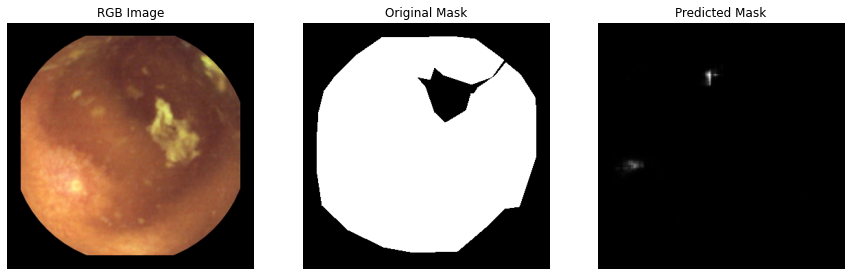

The image with index 29 has the most overlapping pixels with 79572 overlapping pixels.


In [ ]:
# Find the image with the highest number of overlapping pixels
max_overlap = 0
max_overlap_index = 0
for i in overlap:
    orig_mask = masks[i]
    pred_mask = pred_masks[i]

    # Find the overlapping pixels
    overlap_mask = np.logical_and(orig_mask, pred_mask)
    num_overlap_pixels = np.sum(overlap_mask)

    # If this image has more overlapping pixels than the previous max, update the max
    if num_overlap_pixels > max_overlap:
        max_overlap = num_overlap_pixels
        max_overlap_index = i

# Plot the image with the highest number of overlapping pixels
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(data[max_overlap_index])
axs[0].set_title("RGB Image")
axs[0].axis("off")
axs[1].imshow(masks[max_overlap_index], cmap='gray')
axs[1].set_title("Original Mask")
axs[1].axis("off")
axs[2].imshow(pred_masks[max_overlap_index], cmap='gray')
axs[2].set_title("Predicted Mask")
axs[2].axis("off")
plt.show()

print(f"The image with index {max_overlap_index} has the most overlapping pixels with {max_overlap} overlapping pixels.")